# Operational Risk Detection & Prioritization — Public Evidence Notebook

**Case study:** detect operational risk events raised on monitored entities
(accounts, devices, services, vendors, integrations) and prioritize a
**limited review capacity** (synthetic).

> ⚠️ **Synthetic data disclaimer.** Every row in `operational_risk_dataset.csv`
> is generated data — no real entities, telemetry, incidents, or
> organizations are represented, and there is no PHI/PII of any kind. Results
> are for **methodology demonstration** only (synthetic data generation →
> cleaning → EDA → a deterministic rules baseline → leakage-aware feature
> engineering → model comparison → capacity-constrained review policy), not a
> real fraud/security detection system and not a causal claim.

**Reproducibility contract**

| | |
|---|---|
| Dataset | `operational_risk_dataset.csv` (this folder) — 15,000 cleaned events, 22 columns |
| Seed | `42` |
| Target | `is_risk_flag`, modeling population `auto_resolved_flag == 0` |
| Split | Simple temporal train / validation / test by `event_timestamp` (~65/15/20, positional) |
| Baseline | Fixed, interpretable rules (severity, off-hours, sensitive event types, cold-start history, burst) |
| Selected model | Logistic Regression (validation PR-AUC) |
| Review policy | **Top 12% by score**, applied independently per split — not an absolute threshold, not 0.5 |

This notebook is fully self-contained: it only reads `operational_risk_dataset.csv`
(and, in the closing check, `portfolio_manifest.json`) from this same folder,
and only uses public libraries (pandas / numpy / scikit-learn / matplotlib).
It does not import any Paradigm application code or private
`case_studies/operational_risk/` modules — it *reproduces* their documented
methodology from public data alone, and the closing section checks that
reproduction against the published manifest.

Full scenario, data model and data dictionary: see `README.md` and
`data_dictionary.xlsx` in this folder.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25})

SEED = 42
TARGET = "is_risk_flag"
np.random.seed(SEED)

## 1. Load & data quality

The dataset here is already the **cleaned** analytical table (equivalent to
`processed/events_cleaned.csv` in the source repo) — deduplicated, with
normalized categorical casing, corrected entity-type joins, and corrected
`value_amount` signs. Post-event / leakage columns
(`resolution_minutes`, `analyst_notes_length`, `confirmed_loss_amount`) are
preserved unmodified — never dropped, never used as predictors below.

In [2]:
DATA_PATH = Path("operational_risk_dataset.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["event_timestamp"])
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns from '{DATA_PATH.name}'")
df.head(3)

Loaded 15,000 rows x 22 columns from 'operational_risk_dataset.csv'


,event_id,entity_id,event_timestamp,event_type,source_system,severity_reported,value_amount,entity_type,region,tier,risk_segment_baseline,entity_age_days,prior_events_count,prior_flagged_count,time_since_last_event_hours,hour_of_day,day_of_week,auto_resolved_flag,is_risk_flag,resolution_minutes,analyst_notes_length,confirmed_loss_amount
0,1,1148,2023-01-01 01:51:00,payment_dispute,web,medium,190.81,vendor,zone_central,plus,low,0,0,0,NaN,1,6,0,0,6.12,66.0,NaN
1,2,757,2023-01-01 07:21:07,config_change,web,low,180.46,device,zone_central,standard,medium,443,0,0,NaN,7,6,1,0,NaN,NaN,NaN
2,3,591,2023-01-01 09:13:37,login_anomaly,batch,low,47.51,integration,zone_south,plus,low,695,0,0,NaN,9,6,0,0,29.67,44.0,NaN


In [3]:
quality = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "duplicate_event_id_rows": int(df["event_id"].duplicated().sum()),
    "structural_violation (auto_resolved=1 & is_risk_flag=1)": int(
        ((df["auto_resolved_flag"] == 1) & (df["is_risk_flag"] == 1)).sum()
    ),
    "date_range_start": df["event_timestamp"].min().date().isoformat(),
    "date_range_end": df["event_timestamp"].max().date().isoformat(),
})
print(quality.to_string())

nulls = df.isna().sum()
nulls = nulls[nulls > 0]
print("\nColumns with nulls (expected: post-review fields, and time_since_last_event_hours on an entity's first event):")
print(nulls.to_string())

rows                                                            15000
columns                                                            22
duplicate_event_id_rows                                             0
structural_violation (auto_resolved=1 & is_risk_flag=1)             0
date_range_start                                           2023-01-01
date_range_end                                             2025-06-30

Columns with nulls (expected: post-review fields, and time_since_last_event_hours on an entity's first event):
time_since_last_event_hours     1372
resolution_minutes              3666
analyst_notes_length            3666
confirmed_loss_amount          14186


## 2. Brief EDA

Modeling population: **`auto_resolved_flag == 0`** (events actually reviewed
— auto-resolved events were dismissed by a rule engine before any human/model
review and can never carry `is_risk_flag = 1`).

Eligible population: 11,334  |  positive rate: 7.18%  (814 / 11334)
Class imbalance (negative:positive): 1:12.9


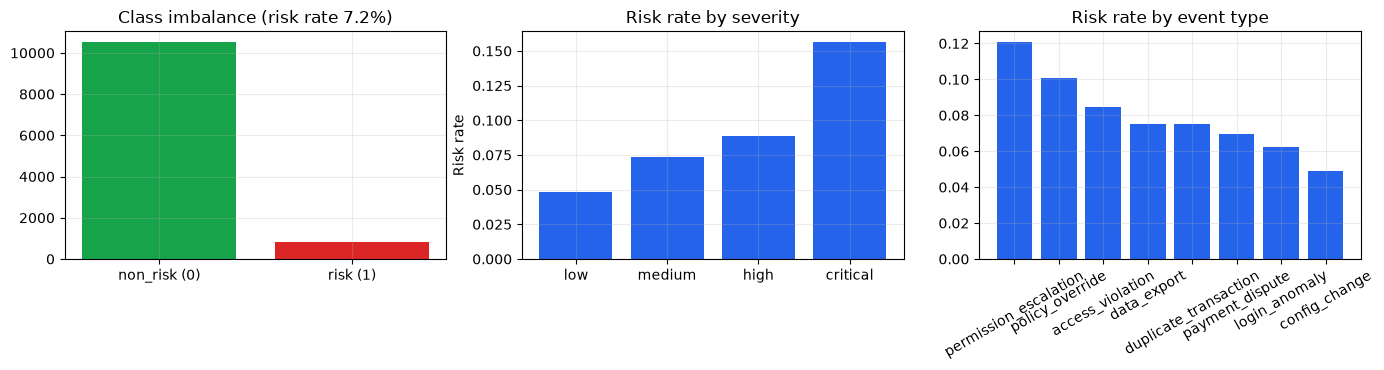

In [4]:
eligible = df[df["auto_resolved_flag"] == 0].copy()
n_elig = len(eligible)
n_pos = int(eligible[TARGET].sum())
risk_rate = eligible[TARGET].mean()
print(f"Eligible population: {n_elig:,}  |  positive rate: {risk_rate:.2%}  ({n_pos} / {n_elig})")
print(f"Class imbalance (negative:positive): 1:{(n_elig - n_pos) / n_pos:.1f}")

by_severity = eligible.groupby("severity_reported")[TARGET].mean().reindex(["low", "medium", "high", "critical"])
by_event_type = eligible.groupby("event_type")[TARGET].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
counts = eligible[TARGET].value_counts().reindex([0, 1])
axes[0].bar(["non_risk (0)", "risk (1)"], counts.values, color=["#16a34a", "#dc2626"])
axes[0].set_title(f"Class imbalance (risk rate {risk_rate:.1%})")

axes[1].bar(by_severity.index, by_severity.values, color="#2563eb")
axes[1].set_title("Risk rate by severity")
axes[1].set_ylabel("Risk rate")

axes[2].bar(by_event_type.index, by_event_type.values, color="#2563eb")
axes[2].set_title("Risk rate by event type")
axes[2].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

## 3. Rules baseline (fixed, pre-ML)

A deterministic, interpretable rule set defined **before** any ML — every
condition uses only pre-event columns, and neither the rules nor the flagging
threshold are tuned against `is_risk_flag`.

In [5]:
SENSITIVE_EVENT_TYPES = ("permission_escalation", "policy_override", "access_violation")
OFF_HOURS_START, OFF_HOURS_END = 22, 6
COLD_START_AGE_DAYS = 60
BURST_GAP_HOURS = 1.0
RULE_SCORE_THRESHOLD = 2


def apply_rules(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    r1 = out["severity_reported"].isin(["high", "critical"])
    r2 = (out["hour_of_day"] >= OFF_HOURS_START) | (out["hour_of_day"] < OFF_HOURS_END)
    r3 = out["event_type"].isin(SENSITIVE_EVENT_TYPES)
    r4 = (out["entity_age_days"] < COLD_START_AGE_DAYS) & (out["prior_flagged_count"] > 0)
    r5 = out["time_since_last_event_hours"].notna() & (out["time_since_last_event_hours"] < BURST_GAP_HOURS)
    out["rule_score"] = r1.astype(int) + r2.astype(int) + r3.astype(int) + r4.astype(int) + r5.astype(int)
    out["rule_flag"] = (out["rule_score"] >= RULE_SCORE_THRESHOLD).astype(int)
    return out


eligible = apply_rules(eligible)
print("Rule score distribution:")
print(eligible["rule_score"].value_counts().sort_index().to_string())
print(f"\nFlagged overall (rule_score >= {RULE_SCORE_THRESHOLD}): {eligible['rule_flag'].mean():.2%}")

Rule score distribution:
rule_score
0    5376
1    4538
2    1272
3     143
4       5

Flagged overall (rule_score >= 2): 12.53%


## 4. Feature engineering + leakage prevention

Predictors are restricted to information knowable **at event-detection
time**. Excluded from the feature set: identifiers (`event_id`,
`entity_id`), `event_timestamp` itself (it drives the split instead),
`auto_resolved_flag` (population filter, not a predictor), and the
post-review / leakage columns (`resolution_minutes`, `analyst_notes_length`,
`confirmed_loss_amount`).

Every engineered feature below is either **row-local** (calendar / value
transforms) or a **strictly-earlier-events** aggregate per entity — the cell
after feature engineering proves the latter by recomputing history from
scratch and diffing against the stored counts.

In [6]:
FEATURE_NUMERIC = [
    "entity_age_days", "prior_events_count", "prior_flagged_count", "prior_flagged_rate",
    "is_first_event", "time_since_last_event_hours_filled", "hour_sin", "hour_cos",
    "day_of_week", "is_weekend", "is_off_hours", "month",
    "value_amount", "log_value_amount", "log_value_amount_sq",
]
FEATURE_CATEGORICAL = [
    "event_type", "source_system", "severity_reported", "entity_type",
    "region", "tier", "risk_segment_baseline",
]
FEATURE_COLUMNS = FEATURE_NUMERIC + FEATURE_CATEGORICAL
FORBIDDEN_IN_X = {
    "event_id", "entity_id", "event_timestamp", "auto_resolved_flag", TARGET,
    "resolution_minutes", "analyst_notes_length", "confirmed_loss_amount",
}
FIRST_EVENT_GAP_SENTINEL_HOURS = 720.0


def build_feature_frame(elig: pd.DataFrame) -> pd.DataFrame:
    out = elig.copy()
    prev = out["prior_events_count"].astype(float)
    prev_flag = out["prior_flagged_count"].astype(float)
    out["prior_flagged_rate"] = np.where(prev > 0, prev_flag / prev, 0.0)
    out["is_first_event"] = (out["prior_events_count"] == 0).astype(int)
    out["time_since_last_event_hours_filled"] = out["time_since_last_event_hours"].fillna(FIRST_EVENT_GAP_SENTINEL_HOURS)

    hour_frac = out["hour_of_day"].astype(float) / 24.0
    out["hour_sin"] = np.sin(2 * np.pi * hour_frac)
    out["hour_cos"] = np.cos(2 * np.pi * hour_frac)
    out["is_weekend"] = (out["day_of_week"] >= 5).astype(int)
    out["is_off_hours"] = ((out["hour_of_day"] >= 22) | (out["hour_of_day"] < 6)).astype(int)
    out["month"] = out["event_timestamp"].dt.month.astype(int)

    out["log_value_amount"] = np.log1p(out["value_amount"].clip(lower=0))
    out["log_value_amount_sq"] = out["log_value_amount"] ** 2
    return out


feature_df = build_feature_frame(eligible)

overlap = set(FEATURE_COLUMNS) & FORBIDDEN_IN_X
print(f"[LEAKAGE CHECK] forbidden columns in feature set: {sorted(overlap)}  ->  {'PASS' if not overlap else 'FAIL'}")
print(f"[LEAKAGE CHECK] target in feature set: {TARGET in FEATURE_COLUMNS}  ->  {'PASS' if TARGET not in FEATURE_COLUMNS else 'FAIL'}")
id_like = [c for c in FEATURE_COLUMNS if c.endswith('_id')]
print(f"[LEAKAGE CHECK] id-like columns in feature set: {id_like}  ->  {'PASS' if not id_like else 'FAIL'}")

[LEAKAGE CHECK] forbidden columns in feature set: []  ->  PASS
[LEAKAGE CHECK] target in feature set: False  ->  PASS
[LEAKAGE CHECK] id-like columns in feature set: []  ->  PASS


In [7]:
# Fail-closed check: recompute prior_events_count / prior_flagged_count from
# scratch, walking the FULL cleaned dataset (all auto_resolved statuses —
# history accrues across every event) in chronological order, and diff
# against the stored values. A mismatch would mean a row's history counted
# events that hadn't happened yet, i.e. future information.
d = df.sort_values(["event_timestamp", "event_id"]).reset_index(drop=True)
running_count, running_flagged = {}, {}
checked = mismatches = 0
for row in d.itertuples(index=False):
    eid = int(row.entity_id)
    exp_count = running_count.get(eid, 0)
    exp_flag = running_flagged.get(eid, 0)
    if int(row.auto_resolved_flag) == 0:
        checked += 1
        if exp_count != int(row.prior_events_count) or exp_flag != int(row.prior_flagged_count):
            mismatches += 1
    running_count[eid] = exp_count + 1
    if int(row.is_risk_flag) == 1:
        running_flagged[eid] = exp_flag + 1

status = "PASS" if mismatches == 0 else "FAIL"
print(f"[LEAKAGE CHECK] history features are causal (no future info): checked={checked}, mismatches={mismatches}  ->  {status}")
assert mismatches == 0, "History leakage detected — aborting."

[LEAKAGE CHECK] history features are causal (no future info): checked=11334, mismatches=0  ->  PASS


## 5. Temporal split

Simple positional temporal split: sort by `event_timestamp`, then cut
chronologically into train (~65%) / validation (~15%) / test (~20%). No
shuffling; train always precedes validation, which always precedes test.

In [8]:
TEST_FRACTION, VAL_FRACTION = 0.20, 0.15


def temporal_split(frame: pd.DataFrame):
    d = frame.sort_values(["event_timestamp", "event_id"]).reset_index(drop=True)
    n = len(d)
    n_test = max(1, int(round(n * TEST_FRACTION)))
    n_val = max(1, int(round(n * VAL_FRACTION)))
    n_train = n - n_test - n_val
    return d.iloc[:n_train].copy(), d.iloc[n_train:n_train + n_val].copy(), d.iloc[n_train + n_val:].copy()


train, val, test = temporal_split(feature_df)
split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(train), len(val), len(test)],
    "start": [train.event_timestamp.min().date(), val.event_timestamp.min().date(), test.event_timestamp.min().date()],
    "end": [train.event_timestamp.max().date(), val.event_timestamp.max().date(), test.event_timestamp.max().date()],
    "positive_rate": [train[TARGET].mean(), val[TARGET].mean(), test[TARGET].mean()],
})
assert train.event_timestamp.max() <= val.event_timestamp.min()
assert val.event_timestamp.max() <= test.event_timestamp.min()
assert len(set(train.event_id) & set(val.event_id) & set(test.event_id)) == 0
print("[LEAKAGE CHECK] splits temporally exclusive + no overlapping event_id  ->  PASS")
split_summary

[LEAKAGE CHECK] splits temporally exclusive + no overlapping event_id  ->  PASS


,split,n,start,end,positive_rate
0,train,7367,2023-01-01,2024-08-14,0.068820
1,validation,1700,2024-08-14,2024-12-26,0.085294
2,test,2267,2024-12-26,2025-06-30,0.071460


## 6. Model comparison

Preprocessing (`StandardScaler` for numeric, one-hot encoding for
categorical) and two candidate model families are **fit on train only**:
Logistic Regression (`class_weight="balanced"`) and Random Forest — plus a
majority-class baseline for reference.

In [9]:
def make_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), FEATURE_NUMERIC),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), FEATURE_CATEGORICAL),
        ],
        remainder="drop",
    )


models = {
    "logistic_regression": Pipeline([
        ("pre", make_preprocessor()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ]),
    "random_forest": Pipeline([
        ("pre", make_preprocessor()),
        ("clf", RandomForestClassifier(
            n_estimators=200, min_samples_leaf=5, class_weight="balanced_subsample",
            random_state=SEED, n_jobs=-1,
        )),
    ]),
}

X_train, y_train = train[FEATURE_COLUMNS], train[TARGET].to_numpy()
X_val, y_val = val[FEATURE_COLUMNS], val[TARGET].to_numpy()
X_test, y_test = test[FEATURE_COLUMNS], test[TARGET].to_numpy()

majority_rate = float(y_train.mean())
val_probas, test_probas = {}, {}
fitted = {}
rows = [{
    "model": "majority_baseline",
    "val_roc_auc": 0.5, "val_pr_auc": average_precision_score(y_val, np.full(len(y_val), majority_rate)),
    "test_roc_auc": 0.5, "test_pr_auc": average_precision_score(y_test, np.full(len(y_test), majority_rate)),
}]
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    fitted[name] = mdl
    p_val, p_test = mdl.predict_proba(X_val)[:, 1], mdl.predict_proba(X_test)[:, 1]
    val_probas[name], test_probas[name] = p_val, p_test
    rows.append({
        "model": name,
        "val_roc_auc": roc_auc_score(y_val, p_val), "val_pr_auc": average_precision_score(y_val, p_val),
        "test_roc_auc": roc_auc_score(y_test, p_test), "test_pr_auc": average_precision_score(y_test, p_test),
    })

comparison = pd.DataFrame(rows).set_index("model").round(4)
comparison

,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc
model,,,,
majority_baseline,0.5000,0.0853,0.5000,0.0715
logistic_regression,0.6553,0.1824,0.6540,0.1433
random_forest,0.6335,0.1685,0.5919,0.1231


## 7. Model selection (validation PR-AUC only)

Model family is chosen by **validation average precision (PR-AUC)** —
the primary ranking metric for this heavily imbalanced target — and nothing
else. Final metrics are reported once on the untouched test fold.

Validation PR-AUC by model: {'logistic_regression': 0.1824, 'random_forest': 0.1685}
Selected model: logistic_regression
Final TEST ranking -> ROC-AUC=0.6540  PR-AUC=0.1433


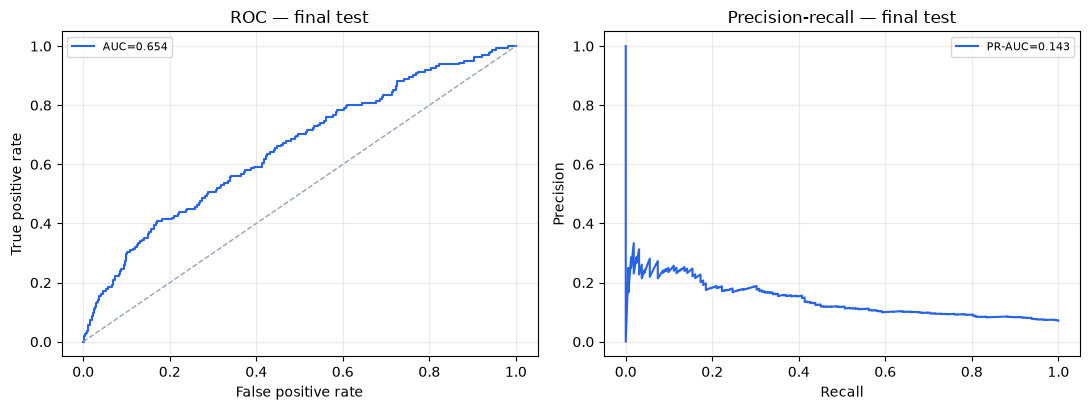

In [10]:
val_pr_auc = {name: average_precision_score(y_val, p) for name, p in val_probas.items()}
selected = max(val_pr_auc, key=val_pr_auc.get)
print(f"Validation PR-AUC by model: { {k: round(v, 4) for k, v in val_pr_auc.items()} }")
print(f"Selected model: {selected}")

selected_val_proba, selected_test_proba = val_probas[selected], test_probas[selected]
test_roc_auc = roc_auc_score(y_test, selected_test_proba)
test_pr_auc = average_precision_score(y_test, selected_test_proba)
print(f"Final TEST ranking -> ROC-AUC={test_roc_auc:.4f}  PR-AUC={test_pr_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
fpr, tpr, _ = roc_curve(y_test, selected_test_proba)
axes[0].plot(fpr, tpr, color="#2563eb", label=f"AUC={test_roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="#94a3b8", linewidth=1)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC — final test"); axes[0].legend(fontsize=8)

prec, rec, _ = precision_recall_curve(y_test, selected_test_proba)
axes[1].plot(rec, prec, color="#2563eb", label=f"PR-AUC={test_pr_auc:.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall — final test"); axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 8. Review policy — Top 12% by score

**Primary operating policy of this case:** review capacity is fixed at **12%**
of each split's eligible volume. Events are ranked by score, descending, with
a **deterministic, pre-target tie-break** (ascending `event_id`), and exactly
the top `round(0.12 * n)` rows are reviewed — independently per split, so the
reviewed share never drifts. This replaces an earlier absolute score
threshold (frozen on validation, then applied as-is to test), which drifted
from 12.0% reviewed on validation to ~15.4% on test because test's score
distribution isn't identical to validation's — kept only as a secondary
diagnostic in `portfolio_manifest.json`, not used here.

In [11]:
CAPACITY_SHARE = 0.12


def rank_topn(frame: pd.DataFrame, score_col: str, n: int) -> pd.DataFrame:
    d = frame.sort_values("event_id", ascending=True)
    d = d.sort_values(score_col, ascending=False, kind="mergesort")
    return d.head(n)


def capacity_n(n_rows: int, share: float) -> int:
    return max(1, int(round(n_rows * share)))


def topn_capacity_metrics(frame: pd.DataFrame, score_col: str, target_col: str, share: float) -> dict:
    n_rows = len(frame)
    n = capacity_n(n_rows, share)
    ranked = rank_topn(frame, score_col, n)
    total_pos = int(frame[target_col].sum())
    tp = int(ranked[target_col].sum())
    fp = n - tp
    precision = tp / n if n else 0.0
    recall = tp / total_pos if total_pos else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    base_rate = total_pos / n_rows if n_rows else 0.0
    lift = precision / base_rate if base_rate else None
    return {
        "n_population": n_rows, "n_reviewed": n, "reviewed_share": n / n_rows,
        "total_positives": total_pos, "true_positives": tp, "false_positives": fp,
        "precision": precision, "recall": recall, "capture_rate": recall, "f1": f1,
        "lift_vs_random": lift,
    }


val_scored = val.copy(); val_scored["risk_score"] = selected_val_proba
test_scored = test.copy(); test_scored["risk_score"] = selected_test_proba

ml_val = topn_capacity_metrics(val_scored, "risk_score", TARGET, CAPACITY_SHARE)
ml_test = topn_capacity_metrics(test_scored, "risk_score", TARGET, CAPACITY_SHARE)
print(f"Validation: N={ml_val['n_reviewed']} ({ml_val['reviewed_share']:.2%})  TP={ml_val['true_positives']}  P={ml_val['precision']:.4f}  R={ml_val['recall']:.4f}")
print(f"Test:       N={ml_test['n_reviewed']} ({ml_test['reviewed_share']:.2%})  TP={ml_test['true_positives']}  P={ml_test['precision']:.4f}  R={ml_test['recall']:.4f}")

Validation: N=204 (12.00%)  TP=41  P=0.2010  R=0.2828
Test:       N=272 (12.00%)  TP=49  P=0.1801  R=0.3025


## 9. ML vs rules baseline — identical review capacity

The rules baseline (Section 3) is scored the exact same way — ranked by
`rule_score`, same deterministic tie-break, same `N` per split — so both
methods are compared under **exactly the same review budget**.

Same N reviewed (validation): True  (204 vs 204)
Same N reviewed (test):       True  (272 vs 272)


,n_reviewed,true_positives,false_positives,precision,recall,f1,lift_vs_random
validation_ML,204.0,41.0,163.0,0.2010,0.2828,0.2350,2.3563
validation_rules,204.0,37.0,167.0,0.1814,0.2552,0.2120,2.1264
test_ML,272.0,49.0,223.0,0.1801,0.3025,0.2258,2.5209
test_rules,272.0,31.0,241.0,0.1140,0.1914,0.1429,1.5949



Headline (test, N=272 both methods): ML captured 49 TP vs rules 31 TP (+18). Precision/Recall/F1 all ~1.58x the rules baseline.


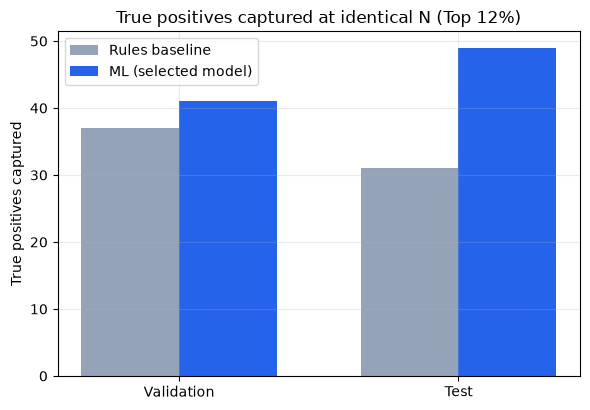

In [12]:
val_ruled = apply_rules(val)
test_ruled = apply_rules(test)

rb_val = topn_capacity_metrics(val_ruled, "rule_score", TARGET, CAPACITY_SHARE)
rb_test = topn_capacity_metrics(test_ruled, "rule_score", TARGET, CAPACITY_SHARE)

same_n_val = ml_val["n_reviewed"] == rb_val["n_reviewed"]
same_n_test = ml_test["n_reviewed"] == rb_test["n_reviewed"]
print(f"Same N reviewed (validation): {same_n_val}  ({ml_val['n_reviewed']} vs {rb_val['n_reviewed']})")
print(f"Same N reviewed (test):       {same_n_test}  ({ml_test['n_reviewed']} vs {rb_test['n_reviewed']})")
assert same_n_val and same_n_test

capacity_table = pd.DataFrame({
    "validation_ML": ml_val, "validation_rules": rb_val,
    "test_ML": ml_test, "test_rules": rb_test,
}).T[["n_reviewed", "true_positives", "false_positives", "precision", "recall", "f1", "lift_vs_random"]]
display(capacity_table.round(4))

additional_tp = ml_test["true_positives"] - rb_test["true_positives"]
ratio = ml_test["f1"] / rb_test["f1"]
print(
    f"\nHeadline (test, N={ml_test['n_reviewed']} both methods): "
    f"ML captured {ml_test['true_positives']} TP vs rules {rb_test['true_positives']} TP "
    f"(+{additional_tp}). Precision/Recall/F1 all ~{ratio:.2f}x the rules baseline."
)

fig, ax = plt.subplots(figsize=(6, 4.2))
x = np.arange(2)
width = 0.35
ax.bar(x - width / 2, [rb_val["true_positives"], rb_test["true_positives"]], width, label="Rules baseline", color="#94a3b8")
ax.bar(x + width / 2, [ml_val["true_positives"], ml_test["true_positives"]], width, label="ML (selected model)", color="#2563eb")
ax.set_xticks(x, ["Validation", "Test"])
ax.set_ylabel("True positives captured")
ax.set_title(f"True positives captured at identical N (Top {CAPACITY_SHARE:.0%})")
ax.legend()
fig.tight_layout()
plt.show()

## 10. Drivers (interpretability)

Scores rank review priority; they are **not calibrated probabilities** and
support no causal claims. Below: fitted Logistic Regression coefficients
(direction of association on the scaled/one-hot feature space) and
permutation importance on the raw pre-event features (drop in test average
precision when a feature is shuffled).

In [13]:
pre = fitted[selected].named_steps["pre"]
clf = fitted[selected].named_steps["clf"]
cat_names = list(pre.named_transformers_["cat"].get_feature_names_out(FEATURE_CATEGORICAL))
onehot_names = FEATURE_NUMERIC + cat_names

if selected == "logistic_regression":
    coef_df = pd.DataFrame({"feature": onehot_names, "coefficient": clf.coef_.ravel()})
    coef_df = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index)
    top = pd.concat([coef_df.head(6), coef_df.tail(6)]).drop_duplicates("feature")
    display(top.sort_values("coefficient", ascending=False))

,feature,coefficient
21,event_type_permission_escalation,0.709932
28,severity_reported_critical,0.640356
14,log_value_amount_sq,0.545098
12,value_amount,0.007263
17,event_type_data_export,0.003612
32,entity_type_account,0.001088
20,event_type_payment_dispute,0.000670
5,time_since_last_event_hours_filled,-0.003040
27,source_system_web,-0.006178
30,severity_reported_low,-0.518409


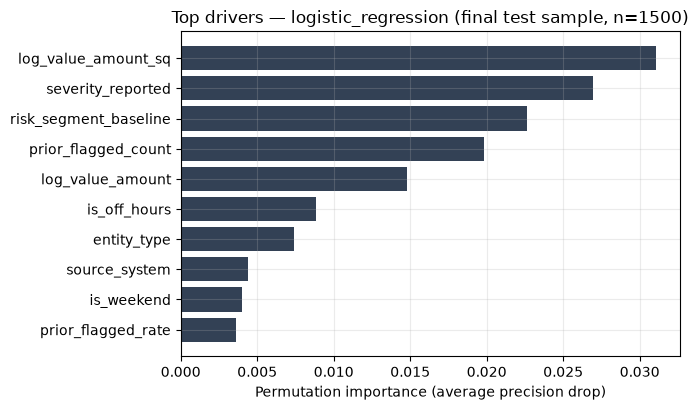

In [14]:
rng = np.random.default_rng(SEED)
sample_n = min(1500, len(X_test))
sample_idx = rng.choice(len(X_test), size=sample_n, replace=False)

perm = permutation_importance(
    fitted[selected], X_test.iloc[sample_idx], y_test[sample_idx],
    n_repeats=8, random_state=SEED, scoring="average_precision", n_jobs=-1,
)
order = np.argsort(perm.importances_mean)[::-1][:10]
perm_df = pd.DataFrame({
    "feature": [FEATURE_COLUMNS[i] for i in order],
    "importance_mean": perm.importances_mean[order],
}).iloc[::-1]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh(perm_df["feature"], perm_df["importance_mean"], color="#334155")
ax.set_xlabel("Permutation importance (average precision drop)")
ax.set_title(f"Top drivers — {selected} (final test sample, n={sample_n})")
fig.tight_layout()
plt.show()

## 11. Concordance check vs. the published Evidence Pack manifest

Since this notebook re-derives everything from raw public data (rather than
loading a frozen model), this section confirms the reproduction lines up with
`portfolio_manifest.json` in this same folder — same split sizes, same
selected model, same headline Top-12% capacity comparison.

In [15]:
manifest = json.loads(Path("portfolio_manifest.json").read_text(encoding="utf-8"))

def _cmp(name, nb_val, mf_val):
    match = "OK" if str(nb_val) == str(mf_val) else "DIFF"
    print(f"{name:28s} notebook={nb_val!s:<14} manifest={mf_val!s:<14} [{match}]")

print("--- split ---")
_cmp("train_rows", len(train), manifest["temporal_split"]["train_rows"])
_cmp("validation_rows", len(val), manifest["temporal_split"]["validation_rows"])
_cmp("test_rows", len(test), manifest["temporal_split"]["test_rows"])

print("\n--- model & ranking (4dp) ---")
_cmp("selected_model", selected, manifest["selected_model"])
_cmp("test_roc_auc", round(test_roc_auc, 4), round(manifest["test_metrics"]["ranking"]["roc_auc"], 4))
_cmp("test_pr_auc", round(test_pr_auc, 4), round(manifest["test_metrics"]["ranking"]["average_precision_pr_auc"], 4))

print("\n--- Top-12% capacity headline (test) ---")
headline = manifest["ml_vs_rules_baseline_at_identical_capacity"]["headline"]
_cmp("test_n_reviewed", ml_test["n_reviewed"], headline["test_n_reviewed_both_methods"])
_cmp("test_ml_true_positives", ml_test["true_positives"], headline["test_ml_true_positives"])
_cmp("test_rules_true_positives", rb_test["true_positives"], headline["test_rules_true_positives"])
_cmp("additional_tp_captured_by_ml", additional_tp, headline["test_additional_true_positives_captured_by_ml"])
_cmp("precision_recall_f1_ratio", round(ratio, 2), round(headline["test_precision_recall_f1_ratio_ml_vs_rules"], 2))

--- split ---
train_rows                   notebook=7367           manifest=7367           [OK]
validation_rows              notebook=1700           manifest=1700           [OK]
test_rows                    notebook=2267           manifest=2267           [OK]

--- model & ranking (4dp) ---
selected_model               notebook=logistic_regression manifest=logistic_regression [OK]
test_roc_auc                 notebook=0.654          manifest=0.654          [OK]
test_pr_auc                  notebook=0.1433         manifest=0.1433         [OK]

--- Top-12% capacity headline (test) ---
test_n_reviewed              notebook=272            manifest=272            [OK]
test_ml_true_positives       notebook=49             manifest=49             [OK]
test_rules_true_positives    notebook=31             manifest=31             [OK]
additional_tp_captured_by_ml notebook=18             manifest=18             [OK]
precision_recall_f1_ratio    notebook=1.58           manifest=1.58           [OK]


## 12. Conclusions & limitations

**Conclusion.** On this synthetic operational-risk population, a Logistic
Regression model ranked by risk score meaningfully outperforms a simple,
interpretable rules baseline **under an identical review budget**: at the
same 272-event test capacity, it captured 49 true positives vs. 31 for the
rules baseline (+18), with precision/recall/F1 all ≈1.58× higher. The
dominant drivers — event severity, sensitive event types, entity risk
segment, prior flagged history, and the engineered `value_amount`
non-linearity — align with the case's documented design.

**Limitations**

- Fully synthetic operational data — no real entities, telemetry, or
  incidents; no PHI/PII.
- Moderate predictive signal (test ROC-AUC ≈ 0.65, PR-AUC ≈ 0.14 against a
  ~7% base rate); scores rank relative risk, they are **not calibrated
  probabilities**.
- The rules baseline is deliberately simple and untuned — a floor for
  comparison, not a competitive alternative.
- No hyperparameter tuning beyond fixed, reasonable defaults.
- No causal claims — associations reflect the generator's intentional
  design, not real-world operational risk patterns.
- Not an automated decision system: the Top-12% policy supports review
  prioritization only, never an automatic accept/deny action.

**Reproduce.** This notebook only needs `operational_risk_dataset.csv` (and,
for the concordance check, `portfolio_manifest.json`) in the same folder — no
other files from the Paradigm repository are required.